Loaded Raw Data: (1509, 12)


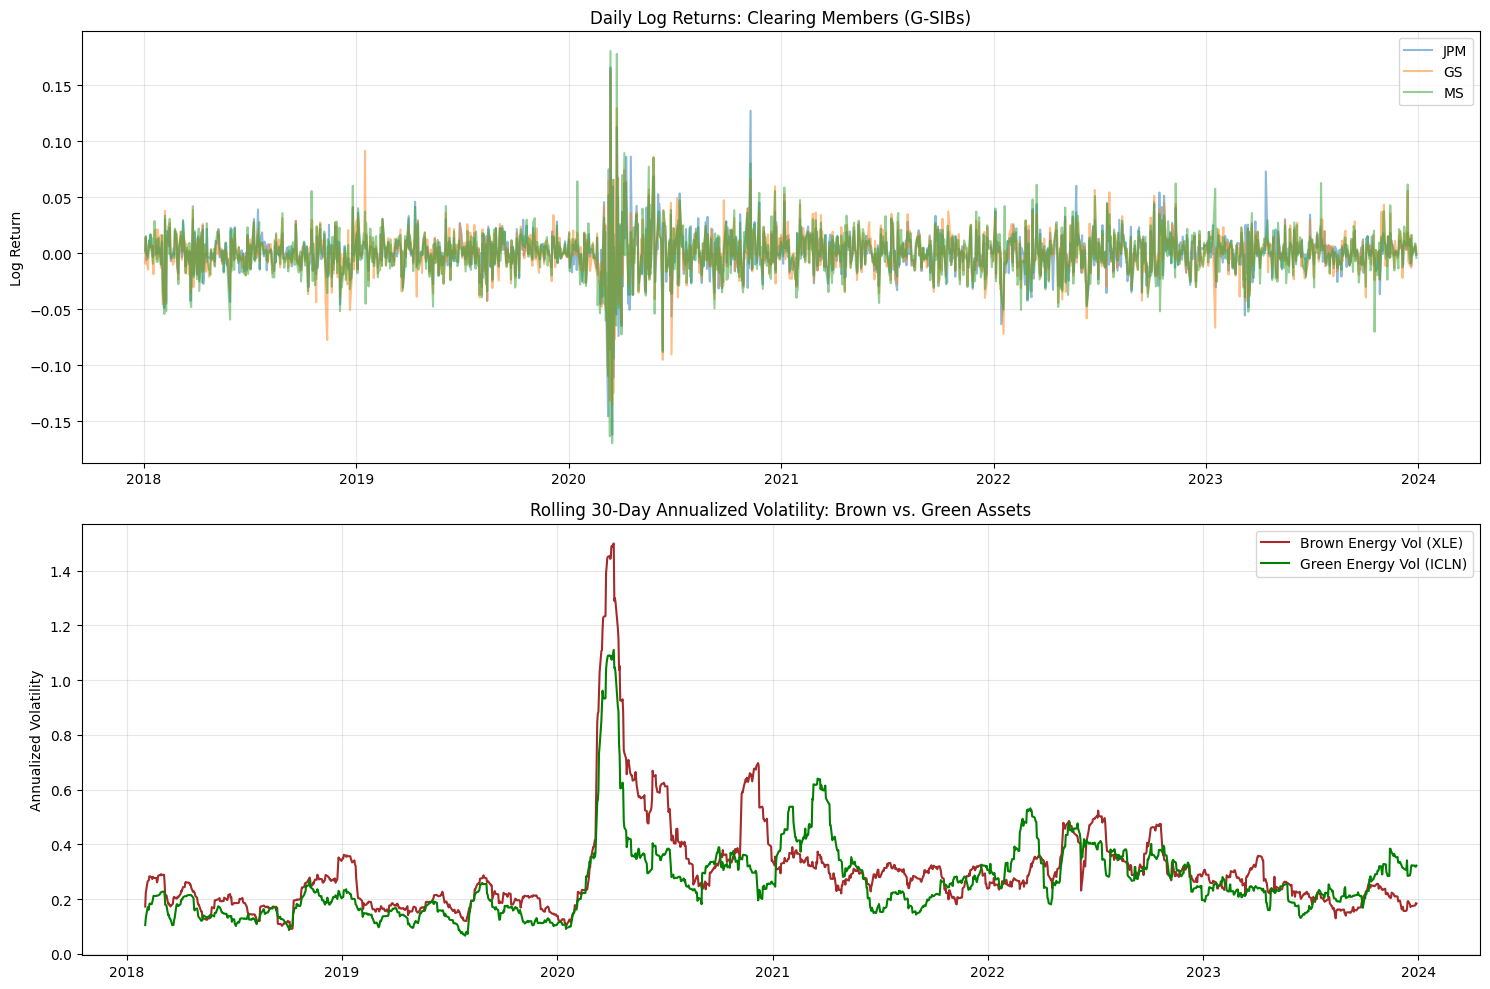


[SUCCESS] Returns data saved to: ..\..\data\processed\market_returns.csv
Statistical Summary of Returns:
             SP500          XLE         ICLN
count  1508.000000  1508.000000  1508.000000
mean      0.000378     0.000275     0.000384
std       0.013075     0.021927     0.019042
min      -0.127652    -0.224910    -0.137092
25%      -0.005018    -0.009786    -0.008933
50%       0.000844     0.000592     0.000000
75%       0.006913     0.010973     0.009895
max       0.089683     0.148742     0.107998


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Load Raw Data
try:
    input_path = os.path.join("..", "..", "data", "raw", "market_data_raw.csv")
    df = pd.read_csv(input_path, index_col=0, parse_dates=True)
except FileNotFoundError:
    input_path = r"c:\Users\Yahya\Desktop\My folder\WQU\10. Capstone\Thesis Work\Risk Management & Sustainability (ESG)\Quantifying Systemic Risk in Central Clearing Counterparties (CCPs)\data\raw\market_data_raw.csv"
    df = pd.read_csv(input_path, index_col=0, parse_dates=True)

print(f"Loaded Raw Data: {df.shape}")

# 2. Calculate Log Returns
# Log returns are additive and time-consistent
returns_df = np.log(df / df.shift(1)).dropna()

# 3. Separate the Data Buckets
cm_tickers = ['JPM', 'GS', 'MS', 'BAC', 'C', 'DB', 'BCS']
macro_tickers = ['SP500', 'VIX', 'US10Y']
esg_tickers = ['XLE', 'ICLN']

# 4. Feature Engineering: Realized Volatility
# We calculate a 21-day (approx 1 trading month) rolling standard deviation
vol_df = returns_df.rolling(window=21).std() * np.sqrt(252) # Annualized

# 5. Visualization: "The Volatility Clusters"
# This confirms the "Stylized Facts" of financial markets (heteroskedasticity)
plt.figure(figsize=(15, 10))

# Plot 1: Clearing Member Returns (The Noise)
plt.subplot(2, 1, 1)
for bank in cm_tickers[:3]: # Plot just top 3 to avoid clutter
    plt.plot(returns_df.index, returns_df[bank], alpha=0.5, label=bank)
plt.title("Daily Log Returns: Clearing Members (G-SIBs)")
plt.legend(loc='upper right')
plt.ylabel("Log Return")
plt.grid(True, alpha=0.3)

# Plot 2: The ESG Divergence (Rolling Volatility)
plt.subplot(2, 1, 2)
plt.plot(vol_df.index, vol_df['XLE'], color='brown', label='Brown Energy Vol (XLE)')
plt.plot(vol_df.index, vol_df['ICLN'], color='green', label='Green Energy Vol (ICLN)')
plt.title("Rolling 30-Day Annualized Volatility: Brown vs. Green Assets")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Save Processed Data
output_path = os.path.join("..", "..", "data", "processed", "market_returns.csv")
os.makedirs(os.path.dirname(output_path), exist_ok=True)
returns_df.to_csv(output_path)

print(f"\n[SUCCESS] Returns data saved to: {output_path}")
print("Statistical Summary of Returns:")
print(returns_df[['SP500', 'XLE', 'ICLN']].describe())